In [24]:
import os
import pandas as pd
import numpy as np



In [220]:
results_dir = r'\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_results\Trial32_Dataset_Amounts_noAug'
results_dir = r'\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_results\Trial32_Dataset_Amounts'


data_n_folders = os.listdir(results_dir)



In [221]:
all_mean_results = {}
all_variance_results = {}
all_CI_results = {}
all_training_incidence_dfs = {}

label_list = ["Aspiration_M06", "Dysphagia_M06", "Sticky_M06", "Taste_M06", "Xerostomia_M06" ]
label_column_names = [x+"_true" for x in label_list]  # to count the incidence of each label in the training set

for n_data_foldername in data_n_folders:
    print(n_data_foldername)
    N_training_patients = int(n_data_foldername.split('_')[-1])
    n_data_folder_dir = os.path.join(results_dir, n_data_foldername)
    random_seed_folders = os.listdir(n_data_folder_dir)

    N_data_dfs_list = []
    train_incidnce_dfs_list = []
    
    for random_seed_foldername in random_seed_folders:
        random_seed_folder_dir = os.path.join(n_data_folder_dir, random_seed_foldername)
        
        test_result_filename = "all_test_metrics.csv"
        test_result_filepath = os.path.join(random_seed_folder_dir, test_result_filename)
        test_result_df = pd.read_csv(test_result_filepath, delimiter=';', index_col=0)
        N_data_dfs_list.append(test_result_df)

        preds_csv_filename = "model_predictions.csv"
        preds_csv_filepath = os.path.join(random_seed_folder_dir, preds_csv_filename)
        preds_df = pd.read_csv(preds_csv_filepath, delimiter=';')
        preds_df = preds_df[preds_df['Mode'] == 'train']

        #print(random_seed_foldername)
        #print(preds_df[label_column_names[-2]].value_counts())
        training_incidence_df = preds_df[label_column_names].apply(lambda x: (x == 1).sum() / (x != -1).sum())
        
        train_incidnce_dfs_list.append(pd.DataFrame(training_incidence_df).T)


    # Concatenate all dataframes in the list
    combined_df = pd.concat(N_data_dfs_list)

    

    # Calculate the mean
    mean_df = combined_df.groupby(combined_df.index).mean().round(3)
    # Calculate the variance
    var_df = combined_df.groupby(combined_df.index).var().round(3)
    # Calculate the confidence interval
    ci_df = combined_df.groupby(combined_df.index).apply(lambda x: 1.96 * x.std() / np.sqrt(len(x))).round(3)

    all_mean_results[N_training_patients] = mean_df
    all_variance_results[N_training_patients] = var_df
    all_CI_results[N_training_patients] = ci_df


    # concatenate all of the training incidence dataframes
    combined_incidences_df = pd.concat(train_incidnce_dfs_list)
    combined_incidences_df.columns = [col.replace('_true', '') for col in combined_incidences_df.columns]

    # calculate the mean of the training incidences
    mean_incidences_df = combined_incidences_df.mean(axis=0).round(2)
    all_training_incidence_dfs[N_training_patients] = mean_incidences_df




n_patients_100
n_patients_200
n_patients_300
n_patients_400
n_patients_500
n_patients_600


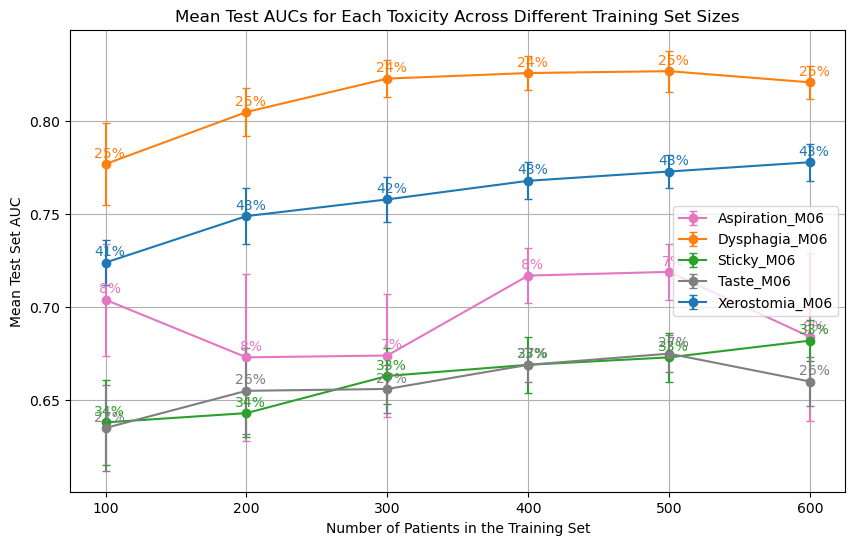

In [228]:
import matplotlib.pyplot as plt

label_list = ["Aspiration_M06", "Dysphagia_M06", "Sticky_M06", "Taste_M06", "Xerostomia_M06" ]
colours = ['tab:pink',  'tab:orange', 'tab:green', 'tab:grey', 'tab:blue', 'tab:orange', 'tab:brown', 'tab:cyan']

metric_name = 'AUC'

# Extract the AUC values from each dataframe in the dictionary
auc_values = {N: df.loc[metric_name] for N, df in all_mean_results.items()}
CI_values = {N: df.loc[metric_name] for N, df in all_CI_results.items()}
std_values = {N: df.loc[metric_name] for N, df in all_variance_results.items()}
#training_set_incidence_values = {N: df for N, df in all_training_incidence_dfs.items()}

# Create a new dataframe for plotting
auc_df = pd.DataFrame(auc_values).T
CI_df = pd.DataFrame(CI_values).T
STD_df = pd.DataFrame(std_values).T
training_incidence_df = pd.DataFrame(all_training_incidence_dfs).T

# Plot the AUC values
plt.figure(figsize=(10, 6))
for idx, endpoint_name in enumerate(label_list):
    #plt.plot(auc_df.index, auc_df[endpoint_name], marker='o', label=endpoint_name, color=colours[idx])
    plt.errorbar(auc_df.index, auc_df[endpoint_name], yerr=CI_df[endpoint_name], marker='o', label=endpoint_name, color=colours[idx], capsize=3)

    for i, txt in enumerate(training_incidence_df[endpoint_name]):
        #print(endpoint_name, txt)
        plt.annotate(f'{txt*100:.0f}%', (auc_df.index[i], auc_df[endpoint_name].iloc[i]), xycoords="data", textcoords="offset points",
                      xytext=(3, 5), ha='center', color=colours[idx])


plt.xlabel('Number of Patients in the Training Set')
plt.ylabel(f'Mean Test Set {metric_name}')
plt.title(f'Mean Test {metric_name}s for Each Toxicity Across Different Training Set Sizes')
#plt.ylim(0.6, 0.85)
plt.legend()
plt.grid(True)
plt.show()

In [224]:
auc_values

{100: MEAN              0.695
 Aspiration_M06    0.704
 Dysphagia_M06     0.777
 Sticky_M06        0.638
 Taste_M06         0.635
 Xerostomia_M06    0.724
 Name: AUC, dtype: float64,
 200: MEAN              0.705
 Aspiration_M06    0.673
 Dysphagia_M06     0.805
 Sticky_M06        0.643
 Taste_M06         0.655
 Xerostomia_M06    0.749
 Name: AUC, dtype: float64,
 300: MEAN              0.715
 Aspiration_M06    0.674
 Dysphagia_M06     0.823
 Sticky_M06        0.663
 Taste_M06         0.656
 Xerostomia_M06    0.758
 Name: AUC, dtype: float64,
 400: MEAN              0.730
 Aspiration_M06    0.717
 Dysphagia_M06     0.826
 Sticky_M06        0.669
 Taste_M06         0.669
 Xerostomia_M06    0.768
 Name: AUC, dtype: float64,
 500: MEAN              0.734
 Aspiration_M06    0.719
 Dysphagia_M06     0.827
 Sticky_M06        0.673
 Taste_M06         0.675
 Xerostomia_M06    0.773
 Name: AUC, dtype: float64,
 600: MEAN              0.725
 Aspiration_M06    0.684
 Dysphagia_M06     0.821
 Stic